In [ ]:
from google.colab import files
uploaded = files.upload()

Saving customer_churn_dataset-training-master.csv to customer_churn_dataset-training-master.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay, roc_curve, auc

print("="*80)
print("CUSTOMER_CHURN_DATASET- CLASSIFICATION")
print("="*80)


CUSTOMER_CHURN_DATASET- CLASSIFICATION


In [ ]:
df = pd.read_csv("customer_churn_dataset-training-master.csv")
df.dropna(inplace=True)

In [ ]:
print(df.head())

   CustomerID   Age  Gender  Tenure  Usage Frequency  Support Calls  \
0         2.0  30.0  Female    39.0             14.0            5.0   
1         3.0  65.0  Female    49.0              1.0           10.0   
2         4.0  55.0  Female    14.0              4.0            6.0   
3         5.0  58.0    Male    38.0             21.0            7.0   
4         6.0  23.0    Male    32.0             20.0            5.0   

   Payment Delay Subscription Type Contract Length  Total Spend  \
0           18.0          Standard          Annual        932.0   
1            8.0             Basic         Monthly        557.0   
2           18.0             Basic       Quarterly        185.0   
3            7.0          Standard         Monthly        396.0   
4            8.0             Basic         Monthly        617.0   

   Last Interaction  Churn  
0              17.0    1.0  
1               6.0    1.0  
2               3.0    1.0  
3              29.0    1.0  
4              20.0    1.

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 440832 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 43.7+ MB
None


In [ ]:
print(df.shape)

(440832, 12)


In [ ]:
print("Duplicate Rows:",df.duplicated().sum())

Duplicate Rows: 0


In [ ]:
print("\nMissing Values")
print(df.isnull().sum())



Missing Values
CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64


In [ ]:
print(df.columns.tolist())

['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction', 'Churn']


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [ ]:
df['Gender'] = le.fit_transform(df['Gender'])
df['Subscription Type'] = le.fit_transform(df['Subscription Type'])
df['Contract Length'] = le.fit_transform(df['Contract Length'])
le.fit_transform(df['Churn'])

array([1, 1, 1, ..., 0, 0, 0])

In [ ]:
X = df.drop(["CustomerID","Churn"] , axis = 1)
y = df['Churn']

In [ ]:
print(y.unique())

[1. 0.]


In [ ]:
# Identify non-numeric columns after label encoding. This should catch any remaining 'object' types.
non_numeric_cols_to_drop = df.select_dtypes(include='object').columns.tolist()

# Define X by dropping CustomerID, Churn (target), and any remaining non-numeric columns
# Use errors='ignore' to prevent KeyError if a column (like 'Subscription type' lowercase) is not present
cols_to_drop = [col for col in ["CustomerID", "Churn"] + non_numeric_cols_to_drop if col in df.columns]
X = df.drop(columns=cols_to_drop, axis=1, errors='ignore')

y = df['Churn']

In [ ]:
# Fill missing values
X = X.fillna(X.mean())

# Scale the data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.linear_model import LogisticRegression

# Create the model
model = LogisticRegression(random_state=42)

# Train the model
model.fit(X_train, y_train)

LogisticRegression(random_state=42)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.850431567366475

Confusion Matrix:
[[32319  5744]
 [ 7443 42661]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.81      0.85      0.83     38063
         1.0       0.88      0.85      0.87     50104

    accuracy                           0.85     88167
   macro avg       0.85      0.85      0.85     88167
weighted avg       0.85      0.85      0.85     88167



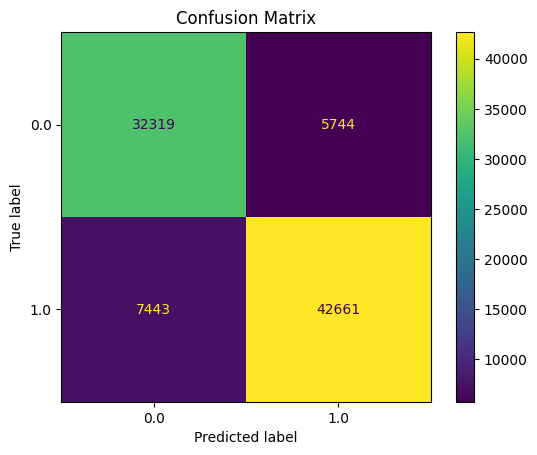

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix")
plt.show()

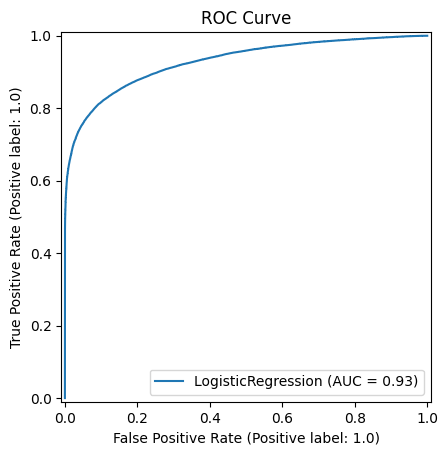

In [ ]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.title("ROC Curve")
plt.show()

In [ ]:
new_data = X_test[0:1]
prediction = model.predict(new_data)

print("Prediction:", prediction)

Prediction: [1.]


In [ ]:
loaded_model = joblib.load("customer_churn_model.pkl")

prediction = loaded_model.predict(X_test[:5])

print("Predicted Values:", prediction)
print("Actual Values:", y_test[:5].values)

Predicted Values: [1. 1. 0. 1. 0.]
Actual Values: [1. 1. 1. 1. 0.]


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "SVM": SVC(kernel='linear', random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier()
}

model_names = []
accuracies = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    model_names.append(name)
    accuracies.append(accuracy_score(y_test, y_pred))

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(model_names, accuracies)
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

In [ ]:
import joblib

joblib.dump(model, "customer_churn_model.pkl")
print("Model saved successfully!")

In [ ]:
loaded_model = joblib.load("customer_churn_model.pkl")

prediction = loaded_model.predict(X_test[:5])

print("Predicted Values:", prediction)
print("Actual Values:", y_test[:5].values)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

# Step 1: Generate synthetic dataset
# 300 samples, 2 features, 3 cluster centers
X, y_true = make_blobs(n_samples=300, centers=3, cluster_std=0.60, random_state=42)

# Step 2: Apply K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X)

# Step 3: Plot the clustered data
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')

# Step 4: Plot cluster centers
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.75, marker='X', label='Centroids')

plt.title("K-Means Clustering Example")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

In [ ]:
import joblib

joblib.dump(model, "customer_churn_model.pkl")
print("Model saved successfully!")